Prediction (PlayTennis): No


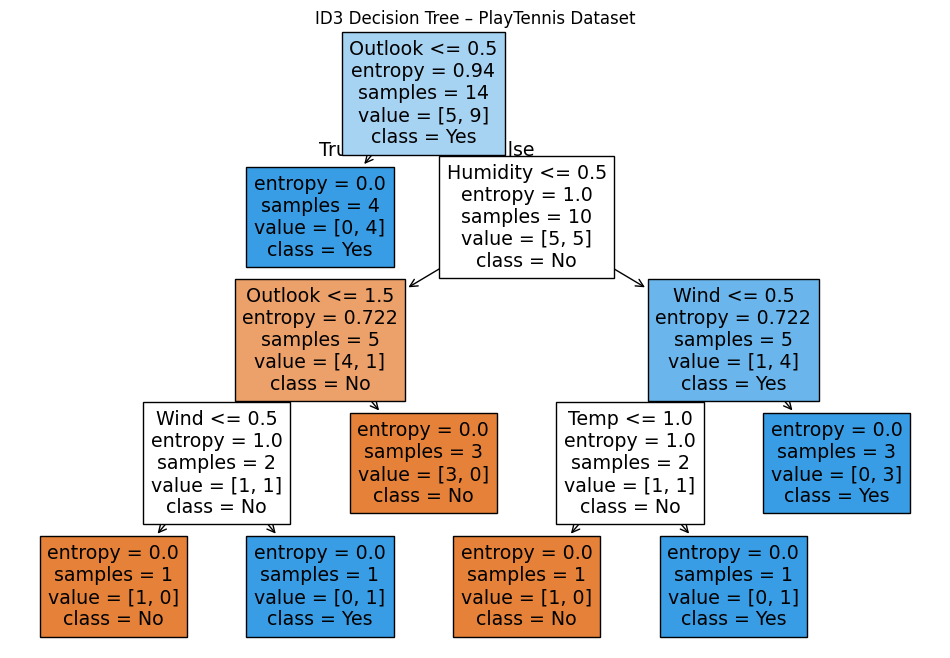

In [ ]:
# Import libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
# Create dataset
data = {
    "Outlook": ["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast",
                "Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain"],
    "Temp": ["Hot","Hot","Hot","Mild","Cool","Cool","Cool",
             "Mild","Cool","Mild","Mild","Mild","Hot","Mild"],
    "Humidity": ["High","High","High","High","Normal","Normal","Normal",
                 "High","Normal","Normal","Normal","High","Normal","High"],
    "Wind": ["Weak","Strong","Weak","Weak","Weak","Strong","Strong",
             "Weak","Weak","Weak","Strong","Strong","Weak","Strong"],
    "PlayTennis": ["No","No","Yes","Yes","Yes","No","Yes",
                   "No","Yes","Yes","Yes","Yes","Yes","No"]
}

df = pd.DataFrame(data)
# Encode categorical variables
label_encoders = {}
for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le
    # Features and target
X = df.drop("PlayTennis", axis=1)
y = df["PlayTennis"]
# Train ID3-like Decision Tree (entropy criterion)
model = DecisionTreeClassifier(criterion="entropy", random_state=42)
model.fit(X, y)
# Predict example
sample = pd.DataFrame({
    "Outlook": [label_encoders["Outlook"].transform(["Sunny"])[0]],
    "Temp": [label_encoders["Temp"].transform(["Cool"])[0]],
    "Humidity": [label_encoders["Humidity"].transform(["High"])[0]],
    "Wind": [label_encoders["Wind"].transform(["Strong"])[0]]
})
prediction = model.predict(sample)
print("Prediction (PlayTennis):",
      label_encoders["PlayTennis"].inverse_transform(prediction)[0])
# Plot tree
plt.figure(figsize=(12,8))
plot_tree(model,
          feature_names=X.columns,
          class_names=label_encoders["PlayTennis"].classes_,
          filled=True)
plt.title("ID3 Decision Tree – PlayTennis Dataset")
plt.show()

Predicted number of Golf Players: 1.0


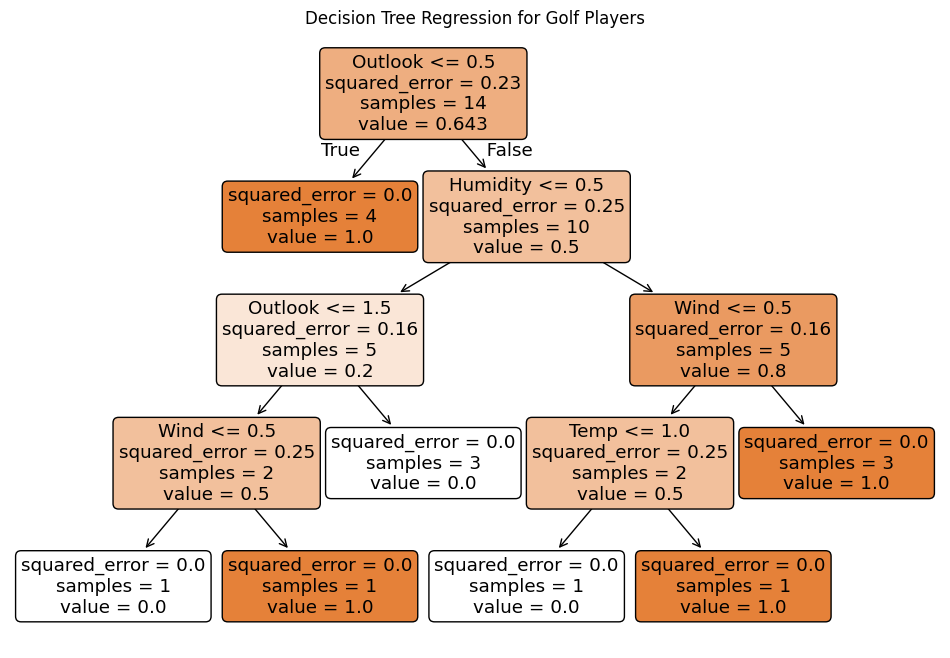

In [4]:
#regressor
# Step 1: Import libraries
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
data = {
    "Outlook": ["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast",
                "Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain"],
    "Temp": ["Hot","Hot","Hot","Mild","Cool","Cool","Cool",
             "Mild","Cool","Mild","Mild","Mild","Hot","Mild"],
    "Humidity": ["High","High","High","High","Normal","Normal","Normal",
                 "High","Normal","Normal","Normal","High","Normal","High"],
    "Wind": ["Weak","Strong","Weak","Weak","Weak","Strong","Strong",
             "Weak","Weak","Weak","Strong","Strong","Weak","Strong"],
    "Golf Players": [25,30,46,45,52,23,43,35,38,46,48,52,44,30]
}
df = pd.DataFrame(data)
# Step 3: Encode categorical features
label_encoders = {}
for column in ["Outlook", "Temp", "Humidity", "Wind"]:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le
    # Step 5: Train Decision Tree Regressor
model = DecisionTreeRegressor(random_state=42)
model.fit(X, y)
# Step 6: Predict for a new sample
# Example: Outlook=Rain, Temp=Mild, Humidity=Normal, Wind=Weak
new_sample = pd.DataFrame({
    "Outlook": [label_encoders["Outlook"].transform(["Rain"])[0]],
    "Temp": [label_encoders["Temp"].transform(["Mild"])[0]],
    "Humidity": [label_encoders["Humidity"].transform(["Normal"])[0]],
    "Wind": [label_encoders["Wind"].transform(["Weak"])[0]]
})
prediction = model.predict(new_sample)
print("Predicted number of Golf Players:", prediction[0])
# Step 7: Visualize the decision tree
plt.figure(figsize=(12, 8))
plot_tree(model,
          feature_names=X.columns,
          filled=True,
          rounded=True)
plt.title("Decision Tree Regression for Golf Players")
plt.show()
